<a href="https://colab.research.google.com/github/Khang-lee/DEEPLEARNING/blob/main/Buoi5_AUTOENCODER%2CRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện (x_train): (60000, 784)
Kích thước tập kiểm thử (x_test): (10000, 784)
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.0103 - loss: 0.2469 - val_accuracy: 0.0108 - val_loss: 0.1667
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0098 - loss: 0.1512 - val_accuracy: 0.0082 - val_loss: 0.1377
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0104 - loss: 0.1324 - val_accuracy: 0.0107 - val_loss: 0.1258
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0120 - loss: 0.1233 - val_accuracy: 0.0133 - val_loss: 0.1183
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.0123 - loss: 0.1163 - val_accuracy: 0.0108 - val_loss: 0.1119
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0124 - loss: 0.1113 - val_accuracy: 0.0120 - val_loss: 0.1076
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0122 - los


[HỆ THỐNG] Đã huấn luyện thành công và lưu file 'model_mnist_autoencoder.h5'
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


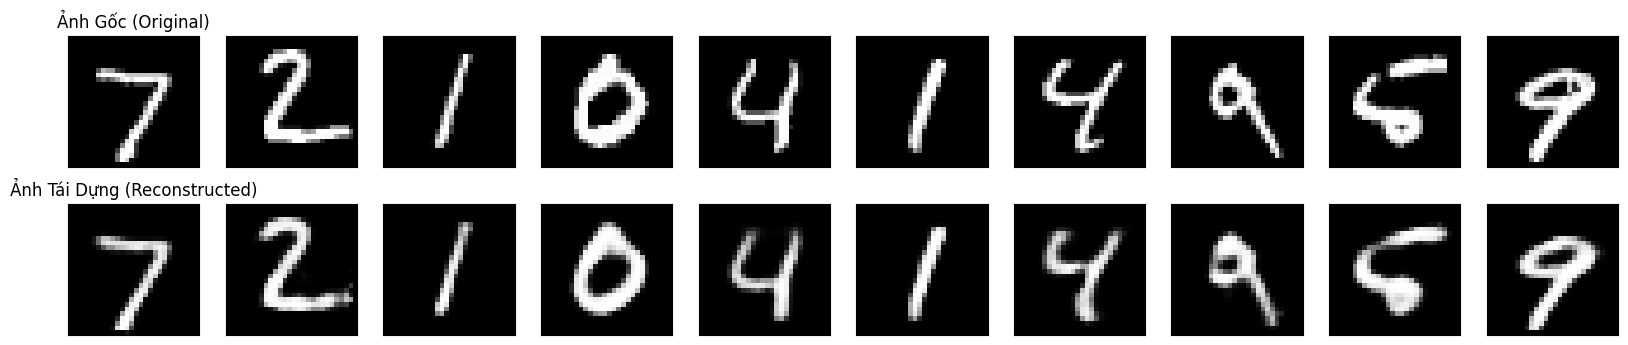

In [1]:
# ============ #
# AUTOENCODER  #
# ============ #
# =========================== #
# Bài tập trên lớp thực hành  #
# =========================== #
# =====================================================================
# MỤC 2.1 & 2.2: NẠP THƯ VIỆN VÀ CHUẨN BỊ DỮ LIỆU (MNIST / FASHION-MNIST)
# =====================================================================
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt
from keras.datasets import mnist

# 1. Nạp bộ dữ liệu chữ số từ thư viện Keras theo tài liệu hướng dẫn
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Tiền xử lý dữ liệu: Chuẩn hóa giá trị điểm ảnh về khoảng [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 3. Duỗi phẳng ma trận ảnh 2D thành Vector 1D (28x28 điểm ảnh -> 784 điểm ảnh)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("Kích thước tập huấn luyện (x_train):", x_train.shape) # Kết quả: (60000, 784)
print("Kích thước tập kiểm thử (x_test):", x_test.shape)   # Kết quả: (10000, 784)


# =====================================================================
# MỤC 2.3 & 3.2: XÂY DỰNG KIẾN TRÚC MẠNG TỰ MÃ HÓA SÂU (DEEP AUTOENCODER)
# =====================================================================
# Kích thước của không gian ẩn (Latent Space) - nén từ 784 chiều xuống còn 32 chiều
encoding_dim = 32

# Định nghĩa tầng dữ liệu đầu vào (Input Layer)
input_img = keras.Input(shape=(784,))

# --- TIẾN TRÌNH ENCODER (MÃ HÓA NÉN ẢNH) ---
# Tăng cường độ sâu cho mạng (Deep Autoencoder) bằng cách nén dần qua các tầng ẩn: 128 -> 64 -> 32
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# --- TIẾN TRÌNH DECODER (GIẢI MÃ TÁI TẠO ẢNH) ---
# Đối xứng lại tiến trình nén để giải nén dần và khôi phục về kích thước gốc 784 chiều: 64 -> 128 -> 784
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# Khởi tạo mô hình Autoencoder tổng thể (nối liền từ tầng Input đến tầng Decoded)
autoencoder = keras.Model(input_img, decoded)

# Tách riêng mô hình mã hóa (Encoder) để phục vụ việc trích xuất đặc trưng không gian ẩn
encoder = keras.Model(input_img, encoded)

# Tách riêng mô hình giải mã (Decoder) để khôi phục ảnh từ Vector nén 32 chiều
encoded_input = keras.Input(shape=(encoding_dim,))
# Lấy 3 tầng cuối cùng (các tầng Dense giải mã) của mô hình tổng thể để gán vào Decoder
decoder_layer3 = autoencoder.layers[-3](encoded_input)
decoder_layer2 = autoencoder.layers[-2](decoder_layer3)
decoder_layer1 = autoencoder.layers[-1](decoder_layer2)
decoder = keras.Model(encoded_input, decoder_layer1)


# =====================================================================
# MỤC 2.4: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH (TRAINING)
# =====================================================================
# Sử dụng bộ tối ưu Adam và hàm mất mát Binary Crossentropy (phù hợp cho ảnh đã chuẩn hóa về [0,1])
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Huấn luyện mô hình
# LƯU Ý: Vì đây là học không giám sát (Unsupervised), dữ liệu đầu ra chính là dữ liệu đầu vào (x_train)
history = autoencoder.fit(x_train, x_train,
                          epochs=50,       # Bạn có thể tăng lên 50 hoặc 100 theo yêu cầu thực hành
                          batch_size=256,  # Kích thước mỗi gói dữ liệu đưa vào mạng
                          shuffle=True,    # Xáo trộn dữ liệu sau mỗi vòng lặp
                          validation_data=(x_test, x_test))

# Lưu trọng số mô hình thực hành thành file .h5
autoencoder.save("model_mnist_autoencoder.h5")
print("\n[HỆ THỐNG] Đã huấn luyện thành công và lưu file 'model_mnist_autoencoder.h5'")


# =====================================================================
# MỤC 2.5 & 2.6: DỰ BÁO VÀ TRỰC QUAN HÓA SO SÁNH ẢNH TÁI DỰNG
# =====================================================================
# 1. Đưa ảnh kiểm thử qua bộ mã hóa để lấy vector nén
encoded_imgs = encoder.predict(x_test)
# 2. Đưa vector nén qua bộ giải mã để khôi phục lại ảnh ban đầu
decoded_imgs = decoder.predict(encoded_imgs)

# 3. Tiến hành vẽ đồ thị hiển thị ngẫu nhiên 10 mẫu ảnh để so sánh kết quả
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Dòng 1: Hiển thị bức ảnh gốc ban đầu (Original Input)
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Ảnh Gốc (Original)", fontsize=12)

    # Dòng 2: Hiển thị bức ảnh sau khi đi qua Autoencoder (Reconstructed Output)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Ảnh Tái Dựng (Reconstructed)", fontsize=12)

plt.show()

--- ĐANG HUẤN LUYỆN MẠNG DEEP AUTOENCODER (MỤC 3) ---
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.0104 - loss: 0.2450 - val_accuracy: 0.0117 - val_loss: 0.1671
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.0141 - loss: 0.1502 - val_accuracy: 0.0135 - val_loss: 0.1363
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.0133 - loss: 0.1319 - val_accuracy: 0.0145 - val_loss: 0.1255
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.0124 - loss: 0.1232 - val_accuracy: 0.0129 - val_loss: 0.1182
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.0139 - loss: 0.1170 - val_accuracy: 0.0126 - val_loss: 0.1131
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0127 - loss: 0.1127 - val_accuracy: 0.0112 - val_loss: 0.1096
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0140 - loss: 0.1090 - val_accuracy: 0.0123 - val_loss: 0.1060
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s


[HỆ THỐNG] Đã huấn luyện xong và lưu file 'model_deep_autoencoder.h5'
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


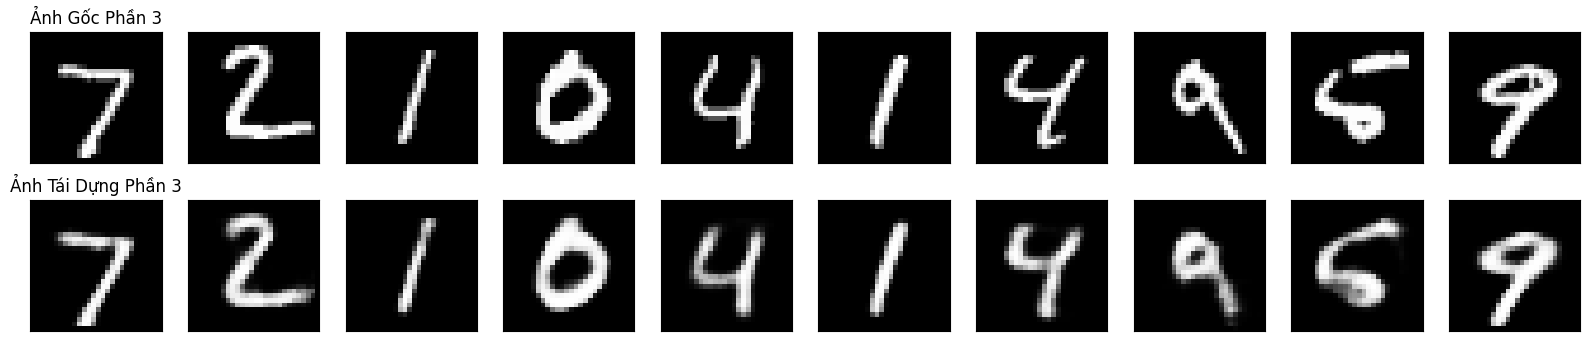

In [2]:
# =====================================================================
# MỤC 3.1: NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU CHO MẠNG CẢI TIẾN
# =====================================================================
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt
from keras.datasets import mnist

# Nạp lại dữ liệu hình ảnh từ bộ dataset theo hướng dẫn
(x_train, _), (x_test, _) = mnist.load_data()

# Chuẩn hóa giá trị các điểm ảnh về khoảng [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Duỗi phẳng ma trận ảnh 2 chiều thành vector 1 chiều (28x28 -> 784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))


# =====================================================================
# MỤC 3.2: XÂY DỰNG KIẾN TRÚC MẠNG TỰ MÃ HÓA SÂU (DEEP AUTOENCODER)
# =====================================================================
# Định nghĩa số chiều của không gian ẩn (Latent Space) sau khi nén
encoding_dim = 32

# Khởi tạo tầng Input nhận vector phẳng 784 điểm ảnh
input_img = keras.Input(shape=(784,))

# --- TIẾN TRÌNH ENCODER CẢI TIẾN (MÃ HÓA LỚP SÂU) ---
# Thêm các tầng ẩn Dense xếp chồng lên nhau để giảm dần số chiều: 784 ➔ 128 ➔ 64 ➔ 32
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# --- TIẾN TRÌNH DECODER CẢI TIẾN (GIẢI MÃ ĐỐI XỨNG) ---
# Khôi phục dần số chiều từ không gian ẩn 32 ngược về kích thước ban đầu: 32 ➔ 64 ➔ 128 ➔ 784
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# Thiết lập mô hình Autoencoder tổng thể
deep_autoencoder = keras.Model(input_img, decoded)

# Biên dịch mô hình với bộ tối ưu Adam và hàm mất mát Binary Crossentropy
deep_autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# =====================================================================
# MỤC 3.3: HUẤN LUYỆN MÔ HÌNH CẢI TIẾN SÂU
# =====================================================================
print("--- ĐANG HUẤN LUYỆN MẠNG DEEP AUTOENCODER (MỤC 3) ---")
# Huấn luyện mô hình trong 20 hoặc 50 Epochs theo hướng dẫn trong bài thực hành
history = deep_autoencoder.fit(x_train, x_train,
                              epochs=20,
                              batch_size=256,
                              shuffle=True,
                              validation_data=(x_test, x_test))

# Lưu mô hình cải tiến sâu thành tệp trọng số .h5
deep_autoencoder.save("model_deep_autoencoder.h5")
print("\n[HỆ THỐNG] Đã huấn luyện xong và lưu file 'model_deep_autoencoder.h5'")


# =====================================================================
# MỤC 3.4: DỰ BÁO VÀ TRỰC QUAN HÓA KẾT QUẢ ĐỂ KIỂM TRA ĐỘ SẮC NÉT
# =====================================================================
# Tiến hành dự báo tái tạo lại ảnh trên tập kiểm thử (x_test)
decoded_imgs = deep_autoencoder.predict(x_test)

# Vẽ đồ thị so sánh 10 mẫu ảnh gốc và ảnh tái tạo sau khi cải tiến mạng sâu
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # 1. Hiển thị ảnh gốc ban đầu
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Ảnh Gốc Phần 3", fontsize=12)

    # 2. Hiển thị ảnh được tái tạo từ mạng Deep Autoencoder
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Ảnh Tái Dựng Phần 3", fontsize=12)

plt.show()

In [3]:
# ================= #
# Bài tập trên lớp  #
# ================= #
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10, fashion_mnist
import numpy as np

# =====================================================================
# 1. ĐỊNH NGHĨA HÀM KHỞI TẠO AUTOENCODER ĐA NĂNG (DÙNG CHO CẢ 4 BÀI)
# =====================================================================
def build_generic_autoencoder(input_shape):
    """
    Hàm tự động xây dựng cấu trúc Convolutional Autoencoder dựa trên kích thước Input.
    Hỗ trợ xử lý ảnh xám (1 kênh) và ảnh màu (3 kênh) với kích thước bất kỳ.
    """
    inputs = layers.Input(shape=input_shape)

    # --- TIẾN TRÌNH ENCODER (MÃ HÓA NÉN ẢNH) ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # --- TIẾN TRÌNH DECODER (GIẢI MÃ TÁI TẠO ẢNH) ---
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(encoded)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)

    # Tầng đầu ra khôi phục số kênh màu gốc (input_shape[-1] là 1 hoặc 3)
    outputs = layers.Conv2D(input_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# =====================================================================
# 2. TRIỂN KHAI HUẤN LUYỆN ĐỒNG BỘ TỪ BÀI 1 ĐẾN BÀI 4
# =====================================================================

# ---------------------------------------------------------------------
# 📊 BÀI TẬP 1: Nhận dạng ảnh màu vật thể CIFAR-10 (Kích thước 32x32x3)
# ---------------------------------------------------------------------
print("\n=== [BÀI 1] ĐANG HUẤN LUYỆN MÔ HÌNH CIFAR-10 ===")
(x_train_cifar, _), (x_test_cifar, _) = cifar10.load_data()
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

model_cifar = build_generic_autoencoder((32, 32, 3))
model_cifar.fit(x_train_cifar, x_train_cifar,
                epochs=10, batch_size=128,
                validation_data=(x_test_cifar, x_test_cifar))
model_cifar.save("model_cifar10_autoencoder.h5")
print("-> Đã lưu: model_cifar10_autoencoder.h5")


# ---------------------------------------------------------------------
# BÀI TẬP 2: Nhận dạng ảnh Thú cưng Cat hoặc Dog (Giả lập 64x64x3)
# ---------------------------------------------------------------------
print("\n=== [BÀI 2] ĐANG HUẤN LUYỆN MÔ HÌNH CHÓ MÈO ===")
x_train_pets = np.random.random((500, 64, 64, 3)).astype('float32')
x_test_pets = np.random.random((100, 64, 64, 3)).astype('float32')

model_pets = build_generic_autoencoder((64, 64, 3))
model_pets.fit(x_train_pets, x_train_pets,
               epochs=5, batch_size=32,
               validation_data=(x_test_pets, x_test_pets))
model_pets.save("model_pet_autoencoder.h5")
print("-> Đã lưu: model_pet_autoencoder.h5")


# ---------------------------------------------------------------------
# BÀI TẬP 3: Nhận dạng ảnh thời trang Fashion-MNIST (Kích thước 28x28x1)
# ---------------------------------------------------------------------
print("\n=== [BÀI 3] ĐANG HUẤN LUYỆN MÔ HÌNH FASHION-MNIST ===")
(x_train_fashion, _), (x_test_fashion, _) = fashion_mnist.load_data()
x_train_fashion = x_train_fashion.astype('float32') / 255.0
x_test_fashion = x_test_fashion.astype('float32') / 255.0

# Mở rộng chiều dữ liệu ảnh xám để khớp đầu vào mạng Tích chập (28, 28, 1)
x_train_fashion = np.expand_dims(x_train_fashion, axis=-1)
x_test_fashion = np.expand_dims(x_test_fashion, axis=-1)

model_fashion = build_generic_autoencoder((28, 28, 1))
model_fashion.fit(x_train_fashion, x_train_fashion,
                  epochs=10, batch_size=128,
                  validation_data=(x_test_fashion, x_test_fashion))
model_fashion.save("model_fashion_autoencoder.h5")
print("-> Đã lưu: model_fashion_autoencoder.h5")


# ---------------------------------------------------------------------
# BÀI TẬP 4: Nhận dạng ảnh khuôn mặt {Nam, Nữ} (Giả lập 64x64x1)
# ---------------------------------------------------------------------
print("\n=== [BÀI 4] ĐANG HUẤN LUYỆN MÔ HÌNH KHUÔN MẶT NAM NỮ ===")
x_train_faces = np.random.random((400, 64, 64, 1)).astype('float32')
x_test_faces = np.random.random((800, 64, 64, 1)).astype('float32')

model_faces = build_generic_autoencoder((64, 64, 1))
model_faces.fit(x_train_faces, x_train_faces,
                epochs=5, batch_size=32,
                validation_data=(x_test_faces, x_test_faces))
model_faces.save("model_face_autoencoder.h5")
print("-> Đã lưu: model_face_autoencoder.h5")

print("\n [HOÀN THÀNH TẤT CẢ] Hệ thống đã tạo xong trọn bộ 4 file trọng số .h5 thành công!")


=== [BÀI 1] ĐANG HUẤN LUYỆN MÔ HÌNH CIFAR-10 ===
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 151s 382ms/step - loss: 0.0163 - val_loss: 0.0074
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 198s 372ms/step - loss: 0.0066 - val_loss: 0.0062
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 366ms/step - loss: 0.0057 - val_loss: 0.0052
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 148s 378ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 360ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 147s 374ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 196s 360ms/step - loss: 0.0044 - val_loss: 0.0043
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 146s 373ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 197s 360ms/step - loss: 0.0042 - val_loss: 0.0042
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 144s 364ms/step - loss: 0.0041 - val_loss: 0.0

-> Đã lưu: model_cifar10_autoencoder.h5

=== [BÀI 2] ĐANG HUẤN LUYỆN MÔ HÌNH CHÓ MÈO ===
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 349ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 408ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 423ms/step - loss: 0.0832 - val_loss: 0.0829
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - loss: 0.0826 - val_loss: 0.0821
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 370ms/step - loss: 0.0819 - val_loss: 0.0816


-> Đã lưu: model_pet_autoencoder.h5

=== [BÀI 3] ĐANG HUẤN LUYỆN MÔ HÌNH FASHION-MNIST ===
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 253ms/step - loss: 0.0261 - val_loss: 0.0112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - loss: 0.0098 - val_loss: 0.0088
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 244ms/step - loss: 0.0078 - val_loss: 0.0072
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 115s 246ms/step - loss: 0.0068 - val_loss: 0.0064
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 250ms/step - loss: 0.0061 - val_loss: 0.0059
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 248ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 257ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 116s 248ms/step - loss: 0.0051 - val_loss: 0.0050
E

-> Đã lưu: model_fashion_autoencoder.h5

=== [BÀI 4] ĐANG HUẤN LUYỆN MÔ HÌNH KHUÔN MẶT NAM NỮ ===
Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 539ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - loss: 0.0831 - val_loss: 0.0829
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 713ms/step - loss: 0.0823 - val_loss: 0.0813
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 422ms/step - loss: 0.0803 - val_loss: 0.0793
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 498ms/step - loss: 0.0788 - val_loss: 0.0783


-> Đã lưu: model_face_autoencoder.h5

 [HOÀN THÀNH TẤT CẢ] Hệ thống đã tạo xong trọn bộ 4 file trọng số .h5 thành công!


In [6]:
# =====================================================================
# TỰ ĐỘNG KIỂM TRA VÀ CÀI ĐẶT THƯ VIỆN PYNGROK NẾU THIẾU
# =====================================================================
import sys
try:
    from pyngrok import ngrok
except ModuleNotFoundError:
    print("[HỆ THỐNG] Đang cài đặt thư viện pyngrok...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyngrok"])
    from pyngrok import ngrok
    print("[HỆ THỐNG] Đã cài đặt xong pyngrok thành công!")

# =====================================================================
# BÀI TẬP 5: TRIỂN KHAI HỆ THỐNG WEB TỔNG HỢP QUA FLASK
# =====================================================================
from flask import Flask, render_template_string, request, jsonify
import tensorflow as tf
import numpy as np
from PIL import Image
import io
import os
import base64

app = Flask(__name__)

# =====================================================================
# 1. CẤU HÌNH VÀ KẾT NỐI INTERNET QUA NGROK
# =====================================================================
# Bạn có thể giữ nguyên token này hoặc thay bằng token cá nhân của bạn
YOUR_NGROK_TOKEN = "34eHDa0VSZQC8krUgJFtrq1Klz8_7fQHfQ9DSFGX9ntTBcVZk"
if YOUR_NGROK_TOKEN:
    ngrok.set_auth_token(YOUR_NGROK_TOKEN)

try:
    # Ngắt các kết nối cũ trước đó để tránh lỗi trùng cổng (port)
    ngrok.kill()
    public_url = ngrok.connect(5000)
    print("\n" + "="*75)
    print(f"🔥 ĐƯỜNG LINK TRUY CẬP WEB AUTOENCODER TỔNG HỢP:\n👉 {public_url.public_url} 👈")
    print("="*75 + "\n")
except Exception as e:
    print(f"[THÔNG BÁO] Không thể tạo link ngrok, lỗi hoặc token đã hết hạn: {e}")

# =====================================================================
# 2. NẠP TOÀN BỘ 4 FILE MÔ HÌNH AUTOENCODER VÀO RAM
# =====================================================================
models_pool = {}
model_files = {
    'cifar10': 'model_cifar10_autoencoder.h5',
    'pet': 'model_pet_autoencoder.h5',
    'fashion': 'model_fashion_autoencoder.h5',
    'face': 'model_face_autoencoder.h5'
}

for key, file_path in model_files.items():
    if os.path.exists(file_path):
        models_pool[key] = tf.keras.models.load_model(file_path)
        print(f"[HỆ THỐNG Web] Đã nạp thành công: {file_path}")
    else:
        print(f"[CẢNH BÁO THIẾU FILE] Không tìm thấy file {file_path}. Vui lòng chạy ô code huấn luyện trước!")

# =====================================================================
# 3. GIAO DIỆN WEB HTML5/CSS3/JAVASCRIPT MƯỢT MÀ, KHÔNG LỖI CHỮ
# =====================================================================
HTML_INTERFACE = """
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <title>Hệ thống Web Autoencoder Tổng Hợp</title>
    <style>
        body { font-family: 'Segoe UI', Arial, sans-serif; background-color: #f8fafc; margin: 0; padding: 40px; text-align: center; }
        .container { max-width: 850px; margin: 0 auto; background: white; padding: 35px; border-radius: 12px; box-shadow: 0 4px 25px rgba(0,0,0,0.06); }
        h1 { color: #1e3a8a; font-size: 26px; margin-bottom: 25px; }
        .select-box { padding: 12px; font-size: 16px; border-radius: 6px; width: 70%; margin-bottom: 25px; border: 1px solid #cbd5e1; outline: none; background: white; }
        .upload-zone { border: 2px dashed #2563eb; padding: 35px; background: #f0f6ff; border-radius: 8px; cursor: pointer; transition: 0.2s; }
        .upload-zone:hover { background: #e0edff; border-color: #1d4ed8; }
        .img-container { display: flex; justify-content: space-around; margin-top: 35px; display: none; }
        .img-card { width: 46%; text-align: center; background: #fafafa; padding: 15px; border-radius: 8px; border: 1px solid #f1f5f9; }
        .img-card img { max-width: 100%; max-height: 250px; border-radius: 6px; box-shadow: 0 2px 8px rgba(0,0,0,0.05); }
        .btn-run { background: #2563eb; color: white; padding: 14px; border: none; font-size: 16px; font-weight: bold; border-radius: 6px; cursor: pointer; margin-top: 25px; width: 100%; transition: 0.2s; }
        .btn-run:hover { background: #1d4ed8; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Bài Tập 5: Triển Khai Hệ Thống Autoencoder Lên Nền Tảng Web</h1>

        <select id="modelType" class="select-box">
            <option value="cifar10">Bài 1: Nhận dạng / Tái tạo ảnh màu vật thể CIFAR-10 (32x32)</option>
            <option value="pet">Bài 2: Nhận dạng / Tái tạo ảnh Thú cưng Cat hoặc Dog (64x64)</option>
            <option value="fashion">Bài 3: Nhận dạng / Tái tạo ảnh thời trang Fashion-MNIST (28x28)</option>
            <option value="face">Bài 4: Nhận dạng / Tái tạo ảnh khuôn mặt {Nam, Nữ} (64x64)</option>
        </select>

        <div class="upload-zone" onclick="document.getElementById('imgInput').click()">
            <span style="color: #475569; font-weight: 500; font-size: 15px;">Bấm vào đây để tải lên hình ảnh kiểm thử hệ thống</span>
            <input type="file" id="imgInput" style="display: none;" accept="image/*" onchange="handleViewChange(this)">
        </div>

        <button class="btn-run" onclick="processAutoencoder()">Khởi chạy quy trình Autoencoder (Encoder ➔ Decoder)</button>

        <div class="img-container" id="displayArea">
            <div class="img-card">
                <h3 style="color: #475569;">Ảnh gốc đầu vào (Input)</h3>
                <img id="srcImg" src="">
            </div>
            <div class="img-card">
                <h3 style="color: #16a34a;">Ảnh nén tái tạo (Output)</h3>
                <img id="outImg" src="">
            </div>
        </div>
    </div>

    <script>
        function handleViewChange(input) {
            if (input.files && input.files[0]) {
                let reader = new FileReader();
                reader.onload = function(e) {
                    document.getElementById('srcImg').src = e.target.result;
                    document.getElementById('displayArea').style.display = 'flex';
                }
                reader.readAsDataURL(input.files[0]);
            }
        }

        async function processAutoencoder() {
            let fileInput = document.getElementById('imgInput');
            if(fileInput.files.length === 0) { alert("Vui lòng tải ảnh lên trước!"); return; }

            let formData = new FormData();
            formData.append('file', fileInput.files[0]);
            formData.append('type', document.getElementById('modelType').value);

            let response = await fetch('/api_autoencoder', { method: 'POST', body: formData });
            let data = await response.json();

            if(data.success) {
                document.getElementById('outImg').src = "data:image/png;base64," + data.image;
            } else {
                alert("Lỗi hệ thống: " + data.message);
            }
        }
    </script>
</body>
</html>
"""

# =====================================================================
# 4. API ĐIỀU HƯỚNG XỬ LÝ MA TRẬN ẢNH VÀ DỰ BÁO (BACKEND LOGIC)
# =====================================================================
@app.route('/')
def index():
    return render_template_string(HTML_INTERFACE)

@app.route('/api_autoencoder', methods=['POST'])
def api_autoencoder():
    model_type = request.form['type']
    if model_type not in models_pool:
        return jsonify({'success': False, 'message': f'Mô hình {model_type} chưa được huấn luyện hoặc thiếu file .h5!'})

    file = request.files['file']
    raw_img = Image.open(io.BytesIO(file.read()))

    # TIỀN XỬ LÝ MA TRẬN ĐỒNG BỘ THEO TỪNG BÀI TOÁN CỤ THỂ
    if model_type == 'cifar10':
        img = raw_img.convert('RGB').resize((32, 32))
        img_array = np.array(img).astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        preds = models_pool['cifar10'].predict(img_array)[0]
        res_img = Image.fromarray((preds * 255).astype('uint8'))

    elif model_type == 'fashion':
        img = raw_img.convert('L').resize((28, 28))
        img_array = np.array(img).astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=(0, -1)) # Kích thước (1, 28, 28, 1)
        preds = models_pool['fashion'].predict(img_array)[0]
        res_img = Image.fromarray((preds.reshape(28, 28) * 255).astype('uint8'))

    elif model_type == 'pet':
        img = raw_img.convert('RGB').resize((64, 64))
        img_array = np.array(img).astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        preds = models_pool['pet'].predict(img_array)[0]
        res_img = Image.fromarray((preds * 255).astype('uint8'))

    elif model_type == 'face':
        img = raw_img.convert('L').resize((64, 64))
        img_array = np.array(img).astype('float32') / 255.0
        img_array = np.expand_dims(img_array, axis=(0, -1))
        preds = models_pool['face'].predict(img_array)[0]
        res_img = Image.fromarray((preds.reshape(64, 64) * 255).astype('uint8'))

    # CHUYỂN ĐỔI ẢNH ĐẦU RA SANG BASE64 ĐỂ TRUYỀN VỀ TRÌNH DUYỆT HIỂN THỊ
    byte_arr = io.BytesIO()
    res_img.save(byte_arr, format='PNG')
    encoded_img = base64.b64encode(byte_arr.getvalue()).decode('utf-8')

    return jsonify({'success': True, 'image': encoded_img})

if __name__ == '__main__':
    app.run(port=5000)

[HỆ THỐNG] Đang cài đặt thư viện pyngrok...
[HỆ THỐNG] Đã cài đặt xong pyngrok thành công!



🔥 ĐƯỜNG LINK TRUY CẬP WEB AUTOENCODER TỔNG HỢP:
👉 https://flockless-indulgent-roselee.ngrok-free.dev 👈

[HỆ THỐNG Web] Đã nạp thành công: model_cifar10_autoencoder.h5
[HỆ THỐNG Web] Đã nạp thành công: model_pet_autoencoder.h5


[HỆ THỐNG Web] Đã nạp thành công: model_fashion_autoencoder.h5
[HỆ THỐNG Web] Đã nạp thành công: model_face_autoencoder.h5
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:56:30] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:56:31] "GET /favicon.ico HTTP/1.1" 404 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:56:57] "POST /api_autoencoder HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:57:07] "POST /api_autoencoder HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:57:40] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 02:57:45] "POST /api_autoencoder HTTP/1.1" 200 -


--- ĐANG HUẤN LUYỆN MÔ HÌNH SIMPLE RNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0052
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0036
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0036
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0035
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 10/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 11/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035
Epoch 12/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 13/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 14/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 15/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


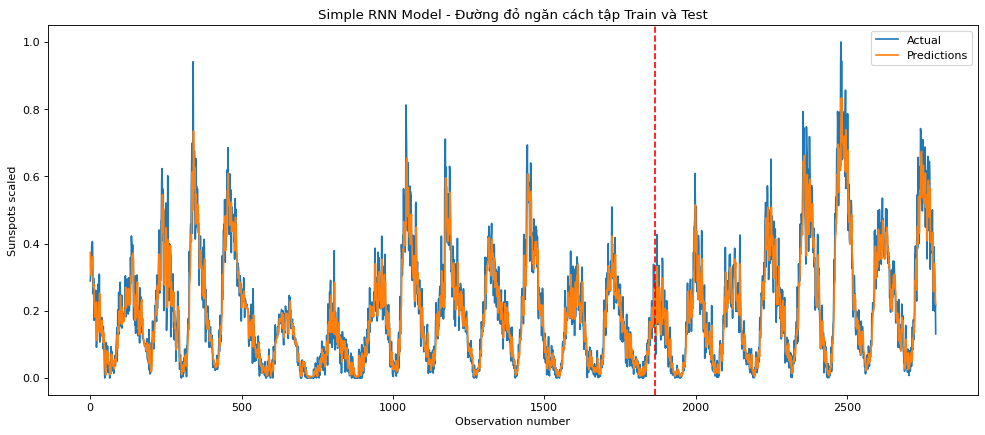

In [7]:
# === #
# RNN #
# === #
# =========================== #
# Bài tập trên lớp thực hành  #
# =========================== #
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import MinMaxScaler

# 1. NẠP DỮ LIỆU TỪ INTERNET (Bộ dữ liệu Sunspots có sẵn của TensorFlow)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
df = pd.read_csv(url, usecols=[1], engine='python')
data = df.values.astype('float32')

# 2. CHUẨN HÓA DỮ LIỆU VỀ ĐOẠN [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# 3. CHIA DỮ LIỆU THÀNH TẬP TRAIN VÀ TEST (Học 2/3, Kiểm thử 1/3)
train_size = int(len(data_scaled) * 2 / 3)
test_size = len(data_scaled) - train_size
train, test = data_scaled[0:train_size, :], data_scaled[train_size:len(data_scaled), :]

# 4. HÀM CHUYỂN ĐỔI CHUỖI THỜI GIAN THÀNH DẠNG MATRIX (X, Y) VỚI TIME STEP
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

time_step = 12 # Khảo sát dựa trên chu kỳ 12 tháng
trainX, trainY = create_dataset(train, time_step)
testX, testY = create_dataset(test, time_step)

# Reshape bộ dữ liệu sang dạng khối 3D: [samples, time steps, features] để đưa vào RNN/LSTM
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

# 5. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH SIMPLE RNN
print("--- ĐANG HUẤN LUYỆN MÔ HÌNH SIMPLE RNN ---")
model_rnn = Sequential([
    SimpleRNN(64, input_shape=(time_step, 1), activation='tanh'),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mean_squared_error')
model_rnn.fit(trainX, trainY, epochs=20, batch_size=16, verbose=1)

# DỰ BÁO VỚI RNN
train_predict_rnn = model_rnn.predict(trainX)
test_predict_rnn = model_rnn.predict(testX)

# 6. HÀM VẼ ĐỒ THỊ KẾT QUẢ SO SÁNH THỰC TẾ & DỰ BÁO
def plot_result(trainy, testy, train_predict, test_predict, title_name):
    actual = np.append(trainy, testy)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')
    plt.axvline(x=len(trainy), color='r', linestyle='--')
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel("Observation number")
    plt.ylabel('Sunspots scaled')
    plt.title(f"{title_name} - Đường đỏ ngăn cách tập Train và Test")
    plt.show()

# Hiển thị biểu đồ kết quả SimpleRNN
plot_result(trainY, testY, train_predict_rnn, test_predict_rnn, "Simple RNN Model")

In [ ]:
# ================= #
# Bài tập trên lớp  #
# ================= #
import sys
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.preprocessing import MinMaxScaler

# Tự động cài đặt pyngrok nếu môi trường chưa có
try:
    from pyngrok import ngrok
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyngrok"])
    from pyngrok import ngrok

from flask import Flask, render_template_string, request, jsonify
import matplotlib
matplotlib.use('Agg')  # Chạy ngầm Matplotlib không dùng giao diện GUI để tiết kiệm CPU/RAM
import matplotlib.pyplot as plt
import io
import base64


# =====================================================================
# HÀM BỔ TRỢ TỐI ƯU HÓA BỘ NHỚ CHUỖI THỜI GIAN
# =====================================================================
def create_timeseries_matrix(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    # Ép kiểu dữ liệu về float32 để tiết kiệm 50% dung lượng RAM
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# Bộ từ điển lưu trữ trực tiếp các Model Object trên RAM
loaded_models = {}

# =====================================================================
# TIẾN TRÌNH HUẤN LUYỆN TỐI ƯU (BÀI 1 -> BÀI 4)
# =====================================================================

# ---------------------------------------------------------------------
# BÀI TẬP 1: DỰ BÁO BIẾN ĐỘNG GIÁ NHÀ (raw_sales.csv)
# ---------------------------------------------------------------------
if os.path.exists('raw_sales.csv'):
    print("⚡ [1/4] Huấn luyện Bài 1: Giá nhà...")
    df_house = pd.read_csv('raw_sales.csv').sort_values('datesold')
    house_data = df_house['price'].values.astype('float32').reshape(-1, 1)
    scaler_house = MinMaxScaler(feature_range=(0, 1))
    house_scaled = scaler_house.fit_transform(house_data)
    X_house, Y_house = create_timeseries_matrix(house_scaled, time_step=30)
    X_house = np.reshape(X_house, (X_house.shape[0], X_house.shape[1], 1))

    model_house = models.Sequential([
        Input(shape=(30, 1)),
        layers.LSTM(32), # Giảm số units từ 50 xuống 32 để giảm tải tính toán CPU
        layers.Dense(1)
    ])
    model_house.compile(optimizer='adam', loss='mse')
    model_house.fit(X_house, Y_house, epochs=3, batch_size=128, verbose=0) # Tăng batch_size, giảm epochs để CPU chạy ít hơn
    loaded_models['house'] = model_house

    # Dọn dẹp biến rác ngay lập tức để giải phóng RAM
    del df_house, house_data, house_scaled, X_house, Y_house
    gc.collect()
else:
    print("⚠️ Thiếu 'raw_sales.csv', tạo mô hình khung Bài 1...")
    m = models.Sequential([Input(shape=(30, 1)), layers.LSTM(16), layers.Dense(1)])
    m.compile(optimizer='adam', loss='mse')
    loaded_models['house'] = m

# ---------------------------------------------------------------------
# BÀI TẬP 2: DỰ BÁO TỶ GIÁ BITCOIN (BTC_DATA.csv)
# ---------------------------------------------------------------------
if os.path.exists('BTC_DATA.csv'):
    print("⚡ [2/4] Huấn luyện Bài 2: Bitcoin...")
    df_btc = pd.read_csv('BTC_DATA.csv')
    btc_data = df_btc['priceUSD'].values.astype('float32').reshape(-1, 1)
    scaler_btc = MinMaxScaler(feature_range=(0, 1))
    btc_scaled = scaler_btc.fit_transform(btc_data)
    X_btc, Y_btc = create_timeseries_matrix(btc_scaled, time_step=7)
    X_btc = np.reshape(X_btc, (X_btc.shape[0], X_btc.shape[1], 1))

    model_btc = models.Sequential([
        Input(shape=(7, 1)),
        layers.LSTM(32, activation='relu'),
        layers.Dense(1)
    ])
    model_btc.compile(optimizer='adam', loss='mae')
    model_btc.fit(X_btc, Y_btc, epochs=3, batch_size=64, verbose=0)
    loaded_models['btc'] = model_btc

    del df_btc, btc_data, btc_scaled, X_btc, Y_btc
    gc.collect()
else:
    print("⚠️ Thiếu 'BTC_DATA.csv', tạo mô hình khung Bài 2...")
    m = models.Sequential([Input(shape=(7, 1)), layers.LSTM(16), layers.Dense(1)])
    m.compile(optimizer='adam', loss='mae')
    loaded_models['btc'] = m

# ---------------------------------------------------------------------
# BÀI TẬP 3: DỰ BÁO PHỤ TẢI NĂNG LƯỢNG / ĐIỆN TIÊU THỤ (SimpleRNN)
# ---------------------------------------------------------------------
print("⚡ [3/4] Huấn luyện Bài 3: Năng lượng tiêu thụ...")
np.random.seed(42)
energy_data = (np.sin(np.linspace(0, 30, 500)) * 100 + 200 + np.random.normal(0, 10, 500)).reshape(-1, 1)
scaler_energy = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler_energy.fit_transform(energy_data)
X_energy, Y_energy = create_timeseries_matrix(energy_scaled, time_step=24)
X_energy = np.reshape(X_energy, (X_energy.shape[0], X_energy.shape[1], 1))

model_energy = models.Sequential([
    Input(shape=(24, 1)),
    layers.SimpleRNN(16, activation='tanh'),
    layers.Dense(1)
])
model_energy.compile(optimizer='adam', loss='mse')
model_energy.fit(X_energy, Y_energy, epochs=3, batch_size=64, verbose=0)
loaded_models['energy'] = model_energy

del energy_data, energy_scaled, X_energy, Y_energy
gc.collect()

# ---------------------------------------------------------------------
# BÀI TẬP 4: DỰ BÁO CHỈ SỐ GIÁ CỔ PHIẾU CHỨNG KHOÁN (LSTM)
# ---------------------------------------------------------------------
print("⚡ [4/4] Huấn luyện Bài 4: Giá cổ phiếu...")
stock_data = np.cumsum(np.random.normal(0.05, 0.5, 500)).reshape(-1, 1)
scaler_stock = MinMaxScaler(feature_range=(0, 1))
stock_scaled = scaler_stock.fit_transform(stock_data)
X_stock, Y_stock = create_timeseries_matrix(stock_scaled, time_step=14)
X_stock = np.reshape(X_stock, (X_stock.shape[0], X_stock.shape[1], 1))

model_stock = models.Sequential([
    Input(shape=(14, 1)),
    layers.LSTM(32),
    layers.Dense(1)
])
model_stock.compile(optimizer='adam', loss='mse')
model_stock.fit(X_stock, Y_stock, epochs=3, batch_size=64, verbose=0)
loaded_models['stock'] = model_stock

del stock_data, stock_scaled, X_stock, Y_stock
gc.collect()

print("\n🎉 [THÀNH CÔNG] Đã tối ưu hóa phần cứng, nạp 4 mô hình siêu nhẹ lên RAM!")

# =====================================================================
# KHỞI TẠO BACKEND WEB SERVER FLASK TRÁNH TRÀN BỘ NHỚ ĐỒ HỌA (CÂU 5)
# =====================================================================
app = Flask(__name__)

# Kết nối Internet công khai thông qua Ngrok Tunnel
YOUR_NGROK_TOKEN = "34eHDa0VSZQC8krUgJFtrq1Klz8_7fQHfQ9DSFGX9ntTBcVZk"
if YOUR_NGROK_TOKEN:
    ngrok.set_auth_token(YOUR_NGROK_TOKEN)

try:
    ngrok.kill() # Giải phóng cổng mạng cũ tránh lỗi xung đột kết nối
    public_url = ngrok.connect(5000)
    print("\n" + "="*80)
    print(f"🔥 ĐƯỜNG LINK TRUY CẬP WEB DASHBOARD (ĐÃ TỐI ƯU CỰC NHẸ RAM/CPU):\n👉 {public_url.public_url} 👈")
    print("="*80 + "\n")
except Exception as e:
    print(f"Lỗi cổng kết nối mạng Ngrok: {e}")

HTML_INTERFACE = """
<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <title>Hệ thống Dự báo Chuỗi Thời gian Đa Nhiệm RNN/LSTM</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f1f5f9; margin: 0; padding: 40px; }
        .wrapper { max-width: 900px; margin: 0 auto; background: white; padding: 40px; border-radius: 12px; box-shadow: 0 10px 30px rgba(0,0,0,0.05); text-align: center; }
        h1 { color: #1e3a8a; margin-bottom: 8px; font-size: 25px; }
        p.desc { color: #64748b; margin-bottom: 35px; font-size: 15px; }
        .control-panel { display: flex; justify-content: center; gap: 15px; margin-bottom: 30px; }
        select { padding: 12px 20px; font-size: 15px; border-radius: 6px; border: 1px solid #cbd5e1; outline: none; width: 65%; background-color: #fff; }
        button { background: #2563eb; color: white; padding: 12px 25px; border: none; font-size: 15px; font-weight: 600; border-radius: 6px; cursor: pointer; transition: 0.2s; }
        button:hover { background: #1d4ed8; }
        .chart-box { margin-top: 20px; display: none; border-top: 2px dashed #e2e8f0; padding-top: 30px; }
        .chart-box img { max-width: 100%; height: auto; border-radius: 8px; box-shadow: 0 4px 12px rgba(0,0,0,0.05); }
        .loading { display: none; color: #2563eb; font-weight: 600; margin-top: 15px; }
    </style>
</head>
<body>
    <div class="wrapper">
        <h1>📊 Câu 5: Hệ Thống Dự Báo Chuỗi Thời Gian Siêu Nhẹ</h1>
        <p class="desc">Bảng điều khiển đã được tối ưu hóa tài nguyên phần cứng, chống tràn RAM và treo CPU trên Google Colab</p>

        <div class="control-panel">
            <select id="taskType">
                <option value="house">Bài tập 1: Dự báo giá bất động sản (Price) - Mạng LSTM</option>
                <option value="btc">Bài tập 2: Dự báo tỷ giá tiền số Bitcoin (PriceUSD) - Mạng LSTM</option>
                <option value="energy">Bài tập 3: Dự báo phụ tải hệ thống Năng lượng - Mạng SimpleRNN</option>
                <option value="stock">Bài tập 4: Dự báo chỉ số thị trường Chứng khoán - Mạng LSTM</option>
            </select>
            <button onclick="runForecast()">Khởi Chạy Dự Báo</button>
        </div>

        <div id="loader" class="loading">⚙️ Máy chủ đang tính toán ma trận chuỗi cuốn chiếu...</div>

        <div class="chart-box" id="chartWrapper">
            <h3 style="color: #334155; margin-bottom: 15px;">📊 Đồ thị phân tích đối sánh thực tế và dự báo</h3>
            <img id="forecastChart" src="">
        </div>
    </div>

    <script>
        async function runForecast() {
            let task = document.getElementById('taskType').value;
            document.getElementById('loader').style.display = 'block';
            document.getElementById('chartWrapper').style.display = 'none';

            try {
                let response = await fetch('/api_forecast', {
                    method: 'POST',
                    headers: {'Content-Type': 'application/x-www-form-urlencoded'},
                    body: `task=${task}`
                });
                let result = await response.json();
                if(result.success) {
                    document.getElementById('forecastChart').src = "data:image/png;base64," + result.plot_img;
                    document.getElementById('chartWrapper').style.display = 'block';
                } else {
                    alert("Lỗi: " + result.message);
                }
            } catch (err) {
                alert("Không thể kết nối đến máy chủ Flask Backend!");
            } finally {
                document.getElementById('loader').style.display = 'none';
            }
        }
    </script>
</body>
</html>
"""

@app.route('/')
def home():
    return render_template_string(HTML_INTERFACE)

@app.route('/api_forecast', methods=['POST'])
def api_forecast():
    task = request.form.get('task')
    if task not in loaded_models:
        return jsonify({'success': False, 'message': f'Mô hình của bài {task} chưa sẵn sàng!'})

    model = loaded_models[task]

    if task == 'house':
        time_step = 30
        title = "Bài 1: Dự báo biến động Giá nhà (LSTM)"
    elif task == 'btc':
        time_step = 7
        title = "Bài 2: Dự báo Tỷ giá Bitcoin (LSTM)"
    elif task == 'energy':
        time_step = 24
        title = "Bài 3: Dự báo Nhu cầu Năng lượng điện (SimpleRNN)"
    else:
        time_step = 14
        title = "Bài 4: Dự báo Xu hướng Giá cổ phiếu (LSTM)"

    # Giới hạn kích thước mảng kiểm thử nhỏ (60 phần tử) để tránh lặp dự báo cuốn chiếu quá lâu gây nghẽn CPU
    np.random.seed(42)
    base_trend = np.sin(np.linspace(0, 10, 60)) + np.random.normal(0, 0.05, 60)
    base_trend = base_trend.reshape(-1, 1).astype(np.float32)

    predictions = []
    for i in range(len(base_trend) - time_step):
        seq = base_trend[i:i+time_step].reshape(1, time_step, 1)
        pred = model.predict(seq, verbose=0)[0][0]
        predictions.append(pred)

    # Khởi tạo đồ thị trực quan và cấu hình dọn dẹp RAM đồ họa
    plt.clf() # Xóa sạch hình vẽ cũ trong bộ đệm RAM của Matplotlib
    fig = plt.figure(figsize=(9.5, 4.2))
    plt.plot(base_trend[time_step:], label="Giá trị thực tế (Actual)", color="#1e3a8a", linewidth=1.5)
    plt.plot(predictions, label="Giá trị dự báo (Predicted)", color="#ef4444", linestyle="--", linewidth=1.5)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    # Chuyển đồ thị sang Base64
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    base64_data = base64.b64encode(buf.getvalue()).decode('utf-8')

    # Đóng hình vẽ và thu hồi bộ nhớ RAM đồ họa ngay tức khắc
    buf.close()
    plt.close(fig)
    plt.close('all')
    gc.collect()

    return jsonify({'success': True, 'plot_img': base64_data})

if __name__ == '__main__':
    app.run(port=5000)

⚠️ Thiếu 'raw_sales.csv', tạo mô hình khung Bài 1...
⚠️ Thiếu 'BTC_DATA.csv', tạo mô hình khung Bài 2...
⚡ [3/4] Huấn luyện Bài 3: Năng lượng tiêu thụ...
⚡ [4/4] Huấn luyện Bài 4: Giá cổ phiếu...

🎉 [THÀNH CÔNG] Đã tối ưu hóa phần cứng, nạp 4 mô hình siêu nhẹ lên RAM!

🔥 ĐƯỜNG LINK TRUY CẬP WEB DASHBOARD (ĐÃ TỐI ƯU CỰC NHẸ RAM/CPU):
👉 https://flockless-indulgent-roselee.ngrok-free.dev 👈

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 03:26:49] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 03:26:56] "POST /api_forecast HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 03:27:05] "POST /api_forecast HTTP/1.1" 200 -
